### Imports

In [1]:
from datetime import date
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Define timeframe for stock data (5 years)

In [2]:
end = date.today()
start = end.replace(
    year=end.year - 5,
    day = min(end.day, 28) if end.month == 2 else end.day
)

start_date = start.strftime("%Y-%m-%d")
end_date = end.strftime("%Y-%m-%d")

### Fetch and clean stock data

In [3]:
def get_stock_data(ticker):
    data = yf.download(ticker, start_date, end_date)
    return data

df = get_stock_data("AAPL")
df.reset_index(inplace=True)
df.columns = df.columns.get_level_values(0)
df.columns.name = None
df.head()

[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2021-03-29,118.233322,119.392379,117.590489,118.486563,80819200
1,2021-03-30,116.782059,117.269056,115.769103,116.986597,85671900
2,2021-03-31,118.973557,120.307926,117.999561,118.486559,118323800
3,2021-04-01,119.801460,120.950775,119.304720,120.444301,75089100
4,2021-04-05,122.626053,122.879294,119.869643,120.648843,88651200


### Plot stock data

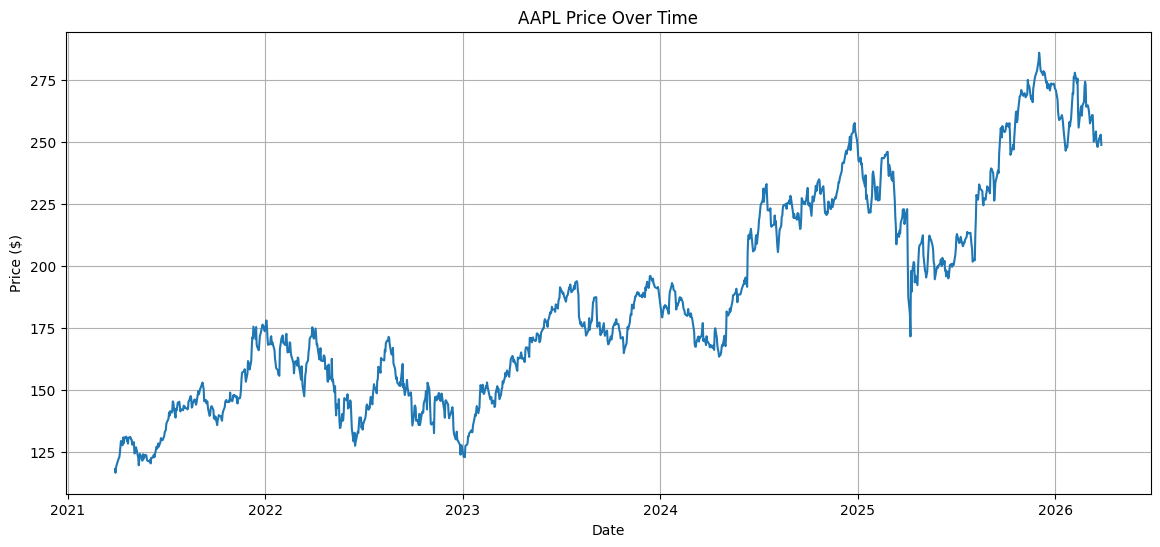

In [4]:
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.show()

### Plot the 9, 21, and 100 EMAs

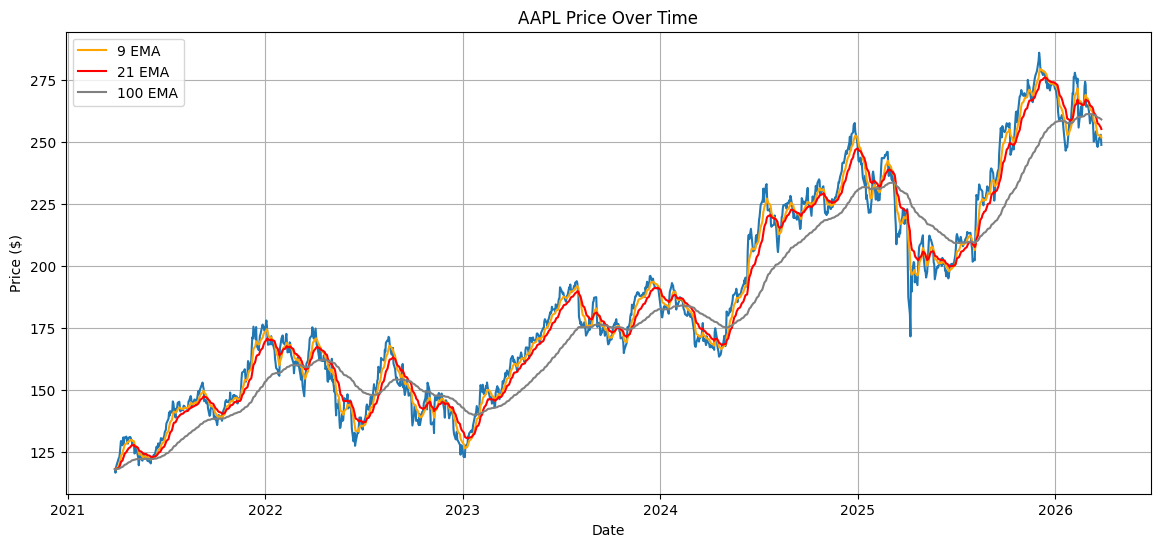

In [5]:
# Calculate EMAs
df["ema9"] = df["Close"].ewm(span=9, adjust=False).mean()
df["ema21"] = df["Close"].ewm(span=21, adjust=False).mean()
df["ema100"] = df["Close"].ewm(span=100, adjust=False).mean()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(df["Date"], df["Close"])
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")

# Plot EMAs
plt.plot(df["Date"], df["ema9"], label="9 EMA", color="orange")
plt.plot(df["Date"], df["ema21"], label="21 EMA", color="red")
plt.plot(df["Date"], df["ema100"], label="100 EMA", color="gray")
plt.legend()

### Create 21 EMA distance, 21 EMA slope, and price return features

In [6]:
df["dist_ema21"] = (df["Close"] - df["ema21"]) / df["ema21"]
df["slope_ema21"] = df["ema21"].diff()
df["return"] = df["Close"].pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-29,118.233322,119.392379,117.590489,118.486563,80819200,118.233322,118.233322,118.233322,0.000000,NaN,NaN
1,2021-03-30,116.782059,117.269056,115.769103,116.986597,85671900,117.943069,118.101389,118.204584,-0.011171,-0.131933,-0.012275
2,2021-03-31,118.973557,120.307926,117.999561,118.486559,118323800,118.149167,118.180677,118.219811,0.006709,0.079288,0.018766
3,2021-04-01,119.801460,120.950775,119.304720,120.444301,75089100,118.479626,118.328021,118.251131,0.012452,0.147344,0.006959
4,2021-04-05,122.626053,122.879294,119.869643,120.648843,88651200,119.308911,118.718751,118.337763,0.032912,0.390730,0.023577


In [7]:
df = df.dropna().reset_index(drop=True)
df.drop(columns=["High", "Low", "Open", "Volume"], inplace=True)
df.head()

,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-30,116.782059,117.943069,118.101389,118.204584,-0.011171,-0.131933,-0.012275
1,2021-03-31,118.973557,118.149167,118.180677,118.219811,0.006709,0.079288,0.018766
2,2021-04-01,119.801460,118.479626,118.328021,118.251131,0.012452,0.147344,0.006959
3,2021-04-05,122.626053,119.308911,118.718751,118.337763,0.032912,0.390730,0.023577
4,2021-04-06,122.927986,120.032726,119.101409,118.428659,0.032129,0.382658,0.002462


### Use a 70/30 train/test split

In [8]:
df.shape

(1255, 8)

In [9]:
split = int(len(df) * 0.7)
train = df[:split]
test = df[split:]

In [10]:
print(train.shape)
train.head()

(878, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
0,2021-03-30,116.782059,117.943069,118.101389,118.204584,-0.011171,-0.131933,-0.012275
1,2021-03-31,118.973557,118.149167,118.180677,118.219811,0.006709,0.079288,0.018766
2,2021-04-01,119.801460,118.479626,118.328021,118.251131,0.012452,0.147344,0.006959
3,2021-04-05,122.626053,119.308911,118.718751,118.337763,0.032912,0.390730,0.023577
4,2021-04-06,122.927986,120.032726,119.101409,118.428659,0.032129,0.382658,0.002462


In [11]:
print(test.shape)
test.head()

(377, 8)


,Date,Close,ema9,ema21,ema100,dist_ema21,slope_ema21,return
878,2024-09-25,224.892685,223.540166,222.341681,211.404977,0.011473,0.255100,-0.004398
879,2024-09-26,226.035202,224.039173,222.677456,211.694685,0.015079,0.335775,0.005080
880,2024-09-27,226.303406,224.492020,223.007088,211.983966,0.014781,0.329632,0.001187
881,2024-09-30,231.479431,225.889502,223.777301,212.370015,0.034419,0.770213,0.022872
882,2024-10-01,224.733765,225.658355,223.864252,212.614842,0.003884,0.086951,-0.029142


### Normalize the dataset

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
features = ["Close", "ema21", "dist_ema21", "slope_ema21", "return"]
target = "Close"

# MinMaxScaler has default param feature_range=(0,1)
features_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Training data
train_features = train[features]
train_target = train[[target]]

# Testing data
test_features = test[features]
test_target = test[[target]]

# Scale training data
train_features_scaled = features_scaler.fit_transform(train_features)
train_target_scaled = target_scaler.fit_transform(train_target)

window = 60

# Scale testing data
prev_window_features = train_features.tail(window)
test_features = pd.concat([prev_window_features, test_features], ignore_index=True)
test_features_scaled = features_scaler.transform(test_features)
test_target_scaled = target_scaler.transform(test_target)

print(train_features_scaled.shape)
print(test_features_scaled.shape)
print(train_target_scaled.shape)
print(test_target_scaled.shape)

(878, 5)
(437, 5)
(878, 1)
(377, 1)


In [14]:
print(train_features_scaled[:3])
print(train_features_scaled[-3:])

[[0.         0.         0.44159097 0.4020658  0.3142816 ]
 [0.0188539  0.00075791 0.53073738 0.46312114 0.5245042 ]
 [0.02597652 0.00216635 0.55937115 0.48279334 0.44454051]]
[[0.94573863 0.98721163 0.61738704 0.59434764 0.37758565]
 [0.93095253 0.99035215 0.57117104 0.53517095 0.34606978]
 [0.93864469 0.99398414 0.582587   0.55003278 0.42432583]]


In [15]:
print(test_features_scaled[:3])
print(test_features_scaled[-3:])

[[0.8457331  0.82803936 0.74959192 0.73967243 0.59452453]
 [0.87578418 0.84007765 0.80211302 0.80423756 0.50739887]
 [0.8867116  0.85212531 0.80049491 0.80452074 0.43676721]]
[[1.16864119 1.31942216 0.42892202 0.33868084 0.42378741]
 [1.17096409 1.31660478 0.43984897 0.35500526 0.40465069]
 [1.13577702 1.31048935 0.37229827 0.25527313 0.28787904]]


In [16]:
print(train_target_scaled[:3])
print(train_target_scaled[-3:])

[[0.        ]
 [0.0188539 ]
 [0.02597652]]
[[0.94573863]
 [0.93095253]
 [0.93864469]]


In [17]:
print(test_target_scaled[:3])
print(test_target_scaled[-3:])

[[0.93009754]
 [0.93992685]
 [0.94223426]]
[[1.16864119]
 [1.17096409]
 [1.13577702]]


### Create training sequences

In [18]:
x_train = []
y_train = []

# For each timestamp (row) x, grab the #(window) timestamps before it and add them as a singular element to x_train. Add timestamp x as an element to y_train.
for i in range(window, train_features_scaled.shape[0]):
    x_train.append(train_features_scaled[i - window : i])
    y_train.append(train_target_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

print(x_train.shape)
print(y_train.shape)

(818, 60, 5)
(818,)


### Create testing sequences

In [19]:
x_test = []
y_test = []

for i in range(window, test_features_scaled.shape[0]):
    x_test.append(test_features_scaled[i - window : i])
    y_test.append(test_target_scaled[i - window, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)

print(x_test.shape)
print(y_test.shape)

(377, 60, 5)
(377,)


### Build LSTM model

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense

In [21]:
model = Sequential()

model.add(Input(shape=(x_train.shape[1], x_train.shape[2])))

model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=32))
model.add(Dropout(0.2))

model.add(Dense(units=1))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,369 (118.63 KB)

 Trainable params: 30,369 (118.63 KB)

 Non-trainable params: 0 (0.00 B)

### Train model

In [22]:
import tensorflow as tf

In [23]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error",
    metrics=[tf.keras.metrics.MeanAbsoluteError()]
)

model.fit(x_train, y_train, epochs=100)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0271 - mean_absolute_error: 0.1218
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0073 - mean_absolute_error: 0.0663
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0055 - mean_absolute_error: 0.0571
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0052 - mean_absolute_error: 0.0560
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0044 - mean_absolute_error: 0.0513
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0045 - mean_absolute_error: 0.0517
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0041 - mean_absolute_error: 0.0482
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0043 - mean_absolute_error: 0.0496
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0042 - mean_absolute_error: 0.0497
Epoch 10/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0043 - mean_absolute_error: 0.0502
Epoch 11/100
26/26 ━━━━━━━━━━

### Make prediction

In [24]:
y_pred = model.predict(x_test)
print(y_pred.shape)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
(377, 1)


In [25]:
print(y_test[:10])

[0.93009754 0.93992685 0.94223426 0.98676465 0.92873032 0.93360191
 0.92411471 0.93377283 0.89009756 0.92496944]


In [26]:
print(y_pred[:10])

[[0.93787086]
 [0.92872155]
 [0.9363704 ]
 [0.9381262 ]
 [0.97889876]
 [0.9283278 ]
 [0.93119943]
 [0.92264104]
 [0.9316168 ]
 [0.8955554 ]]


### Plot prediction

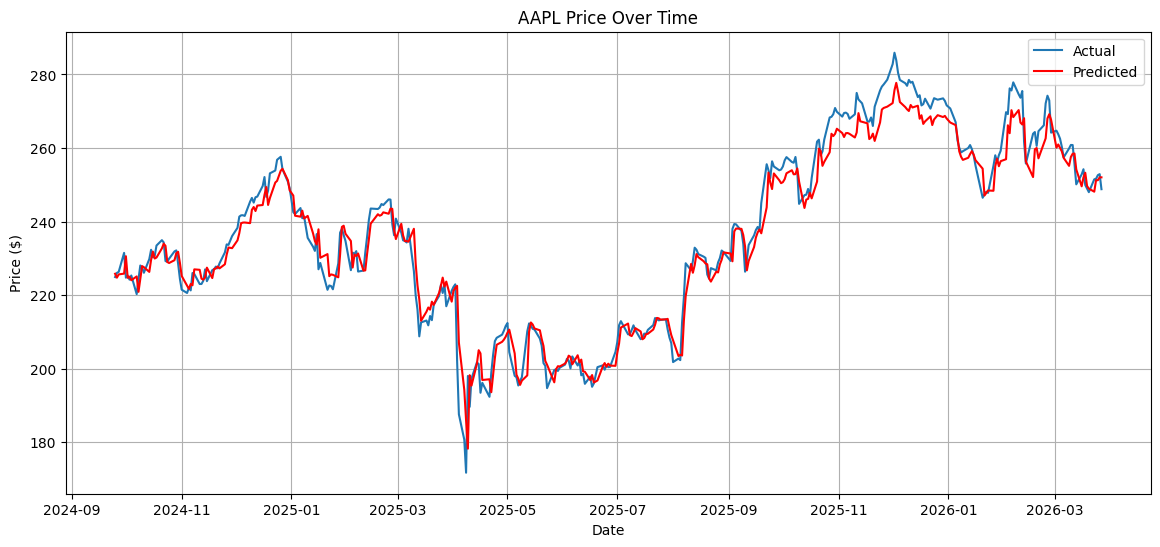

In [27]:
y_pred_prices = target_scaler.inverse_transform(y_pred).flatten()
y_test_prices = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Plot price
plt.figure(figsize=(14, 6))
plt.grid(True)
plt.plot(test["Date"], y_test_prices, label="Actual")
plt.plot(test["Date"], y_pred_prices, label="Predicted", color="red")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.title("AAPL Price Over Time")
plt.legend()